In [1]:
!pip install -q pydicom grad-cam albumentations

import os
import glob
import numpy as np
import pandas as pd
import pydicom
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from pydicom.pixel_data_handlers.util import apply_voi_lut
from sklearn.model_selection import train_test_split

# Percorsi
BASE_PATH = "/kaggle/input/rsna-2022-cervical-spine-fracture-detection"
TRAIN_IMAGES_DIR = os.path.join(BASE_PATH, "train_images")
TRAIN_CSV = os.path.join(BASE_PATH, "train.csv")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 56.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import torch.nn as nn
from torchvision import models

# --- CLASSE DATASET (Assicurati che sia definita qui) ---
class RSNAKaggleDataset(Dataset):
    def __init__(self, df, image_dir):
        self.df = df
        self.image_dir = image_dir

    def __len__(self):
        return len(self.df)

    def preprocess_slice(self, path):
        try:
            dicom = pydicom.dcmread(path)
            img = dicom.pixel_array
            # Applica il contrasto nativo
            if 'WindowCenter' in dicom:
                img = apply_voi_lut(img, dicom)
            
            img = img - np.min(img)
            if np.max(img) != 0: 
                img = img / np.max(img)
            
            # CLAHE per migliorare la visibilità dell'osso
            img_8bit = (img * 255).astype(np.uint8)
            clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
            img = clahe.apply(img_8bit).astype(np.float32) / 255.0
            return cv2.resize(img, (224, 224))
        except Exception as e:
            # Se un file è corrotto, ritorna una matrice nera
            return np.zeros((224, 224), dtype=np.float32)

    def __getitem__(self, idx):
        uid = self.df.iloc[idx]['StudyInstanceUID']
        labels = self.df.iloc[idx][['C1','C2','C3','C4','C5','C6','C7']].values.astype(float)
        
        path = os.path.join(self.image_dir, uid)
        slices = sorted(glob.glob(os.path.join(path, "*.dcm")))
        
        vertebrae_stacks = []
        if len(slices) >= 7:
            # Distribuzione delle fette per coprire le 7 vertebre
            indices = np.linspace(0, len(slices)-1, 9).astype(int)[1:-1]
            for mid in indices:
                s1 = self.preprocess_slice(slices[max(0, mid-1)])
                s2 = self.preprocess_slice(slices[mid])
                s3 = self.preprocess_slice(slices[min(len(slices)-1, mid+1)])
                vertebrae_stacks.append(np.stack([s1, s2, s3], axis=0))
        else:
            # Fallback se il paziente ha pochissime fette
            for _ in range(7): 
                vertebrae_stacks.append(np.zeros((3, 224, 224)))
            
        return torch.tensor(np.array(vertebrae_stacks), dtype=torch.float32), torch.tensor(labels, dtype=torch.float32)

# --- DEFINIZIONE DEL MODELLO ---
class MultiVertebraModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Usiamo ResNet18 pre-addestrata
        base = models.resnet18(weights='DEFAULT')
        # Tengo solo la parte di estrazione caratteristiche (senza l'ultimo strato)
        self.encoder = nn.Sequential(*list(base.children())[:-1])
        self.fc = nn.Linear(512, 1)

    def forward(self, x):
        # x shape: (batch, 7, 3, 224, 224)
        bs, nv, c, h, w = x.shape
        x = x.view(bs * nv, c, h, w) 
        features = self.encoder(x).view(bs * nv, -1)
        out = self.fc(features)
        return out.view(bs, nv)

print("Cella 2 caricata con successo!")

Cella 2 caricata con successo!


In [3]:

def train_kaggle():
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {DEVICE}")
    
    df = pd.read_csv(TRAIN_CSV)
    # Per il primo test su Kaggle, uso solo 50 pazienti per vedere se gira
    df_mini = df.head(50) 
    train_df, val_df = train_test_split(df_mini, test_size=0.2)
    
    train_loader = DataLoader(RSNAKaggleDataset(train_df, TRAIN_IMAGES_DIR), batch_size=2, shuffle=True)
    
    model = MultiVertebraModel().to(DEVICE)
    # Uso BCEWithLogitsLoss per stabilità e pos_weight per le fratture
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([5.0]).to(DEVICE))
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    
    model.train()
    for epoch in range(2): # Inizia con 2 epoche
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            if i % 5 == 0: print(f"Epoch {epoch+1} | Batch {i} | Loss: {loss.item():.4f}")

    torch.save(model.state_dict(), "/kaggle/working/cervical_model.pth")
    print("Modello salvato in /kaggle/working/")

# Esegui il training
train_kaggle()

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 168MB/s]


Epoch 1 | Batch 0 | Loss: 1.2320
Epoch 1 | Batch 5 | Loss: 0.8621
Epoch 1 | Batch 10 | Loss: 1.0631
Epoch 1 | Batch 15 | Loss: 0.8529
Epoch 2 | Batch 0 | Loss: 0.8835
Epoch 2 | Batch 5 | Loss: 0.6494
Epoch 2 | Batch 10 | Loss: 0.3898
Epoch 2 | Batch 15 | Loss: 0.8351
Modello salvato in /kaggle/working/


In [4]:
# uguale alla cella di sopra ma piu robusto
from sklearn.model_selection import train_test_split

def run_training():
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Lavoro su: {DEVICE}")

    # 1. Carichiamo il CSV
    df = pd.read_csv(TRAIN_CSV)
    
    # 2. Per il primo test, prendo solo 100 pazienti (per essere sicuri che funzioni)
    # Se tutto va bene, potrò aumentare questo numero
    df_sample = df.head(100) 
    train_df, val_df = train_test_split(df_sample, test_size=0.2, random_state=42)

    # 3. Preparo i caricatori di dati
    train_loader = DataLoader(RSNAKaggleDataset(train_df, TRAIN_IMAGES_DIR), batch_size=2, shuffle=True)
    val_loader = DataLoader(RSNAKaggleDataset(val_df, TRAIN_IMAGES_DIR), batch_size=2)

    # 4. Inizializzo Modello, Loss e Optimizer
    model = MultiVertebraModel().to(DEVICE)
    # BCEWithLogitsLoss è ideale per classificare C1-C7 contemporaneamente
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([5.0]).to(DEVICE))
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    print("--- Inizio Training (Test su 100 pazienti) ---")
    model.train()
    for epoch in range(2): # Faccio 2 epoche per il test
        epoch_loss = 0
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            if i % 10 == 0:
                print(f"Epoca {epoch+1} | Batch {i} | Loss Corrente: {loss.item():.4f}")

    # 5. Salvataggio finale nell'area di output di Kaggle
    torch.save(model.state_dict(), "/kaggle/working/cervical_model_v1.pth")
    print("--- Training Completato e Modello Salvato! ---")

# Lancio la funzione
run_training()

Lavoro su: cuda
--- Inizio Training (Test su 100 pazienti) ---
Epoca 1 | Batch 0 | Loss Corrente: 1.4991
Epoca 1 | Batch 10 | Loss Corrente: 1.2319
Epoca 1 | Batch 20 | Loss Corrente: 0.8978
Epoca 1 | Batch 30 | Loss Corrente: 1.3146
Epoca 2 | Batch 0 | Loss Corrente: 0.6567
Epoca 2 | Batch 10 | Loss Corrente: 0.5269
Epoca 2 | Batch 20 | Loss Corrente: 0.9455
Epoca 2 | Batch 30 | Loss Corrente: 0.4425
--- Training Completato e Modello Salvato! ---


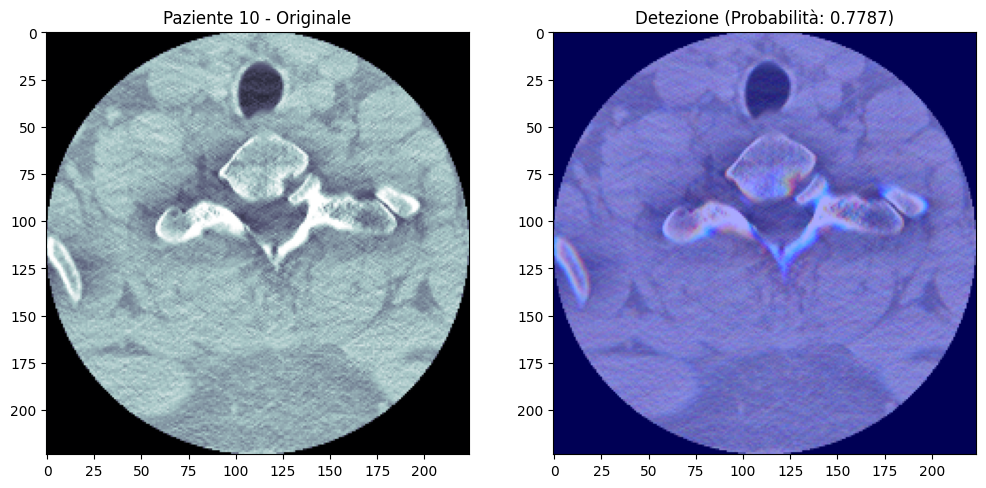

In [5]:
#  IMPORT NECESSARI 
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import cv2
import pydicom
import glob
import os
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# 2. DEFINIZIONE WRAPPER
class GradCAMWrapper(nn.Module):
    def __init__(self, full_model):
        super().__init__()
        self.encoder = full_model.encoder
        self.fc = full_model.fc

    def forward(self, x):
        features = self.encoder(x).view(x.size(0), -1)
        return self.fc(features)

# 3. FUNZIONE DI VISUALIZZAZIONE
def visualize_fracture_detection(model_path, patient_idx=10):
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    
    # Caricamento dati
    df = pd.read_csv(TRAIN_CSV)
    ds = RSNAKaggleDataset(df, TRAIN_IMAGES_DIR)
    images_stack, labels = ds[patient_idx] 
    
    # Caricamento modello
    base_model = MultiVertebraModel().to(DEVICE)
    base_model.load_state_dict(torch.load(model_path))
    base_model.eval()

    wrapped_model = GradCAMWrapper(base_model).to(DEVICE)
    target_layers = [wrapped_model.encoder[-1]]
    
    # importazione GradCAM
    cam = GradCAM(model=wrapped_model, target_layers=target_layers)
    
    v_idx = 3 
    input_tensor = images_stack[v_idx].unsqueeze(0).to(DEVICE)
    targets = [BinaryClassifierOutputTarget(0)]
    
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    
    with torch.no_grad():
        prediction = torch.sigmoid(wrapped_model(input_tensor)).item()
    
    img_to_show = images_stack[v_idx].permute(1, 2, 0).cpu().numpy()
    img_to_show = (img_to_show - img_to_show.min()) / (img_to_show.max() - img_to_show.min() + 1e-9)
    visualization = show_cam_on_image(img_to_show, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img_to_show[:,:,1], cmap='bone')
    plt.title(f"Paziente {patient_idx} - Originale")
    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.title(f"Detezione (Probabilità: {prediction:.4f})")
    plt.show()

#  ESECUZIONE
visualize_fracture_detection("/kaggle/working/cervical_model.pth", patient_idx=10)